## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [17]:
import pandas as pd
import sys
import missingno
import re

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
dataset = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc)

In [4]:
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,22.215876,40.552658,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,4.435606,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN,1043.454545,0
1,23.139532,40.695359,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN,740.125984,0
2,22.758634,41.016242,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,3.765541,7.190461,0.340620,-4.895934,12.183407,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,53.173589,9.279576,14.213017,18.993597,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN,631.285714,0
3,22.109199,40.888821,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,3.694941,6.414831,0.975051,-3.823409,11.261136,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,81.491186,14.713423,22.905129,32.657020,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN,869.318182,0
4,22.441443,40.269748,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000,6.091283,8.354315,3.828251,1.550444,15.961111,8.601499,NaN,NaN,NaN,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,81.927242,15.859868,27.160592,39.731443,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN,1130.755556,0


In [5]:
geomorphological = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [6]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 3.5410560677416845
Max distance: 9.108256052446174


In [7]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [8]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.215876,40.552658,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,4.435606,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN,1043.454545,0,10083.753176,2604.220647,14,151.983874,145.068848,169.450815,0.000000,3.764491
1,23.139532,40.695359,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN,740.125984,0,4609.324076,1275.656385,3,156.077628,106.345725,180.535489,0.000000,3.928386
2,22.758634,41.016242,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,3.765541,7.190461,0.340620,-4.895934,12.183407,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,53.173589,9.279576,14.213017,18.993597,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN,631.285714,0,14539.491549,1973.650189,5,180.265199,154.698694,180.171598,0.000000,10.143914
3,22.109199,40.888821,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,3.694941,6.414831,0.975051,-3.823409,11.261136,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,81.491186,14.713423,22.905129,32.657020,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN,869.318182,0,20467.087760,2556.132830,4,227.370939,344.084297,191.478748,0.000000,1.165700
4,22.441443,40.269748,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.00

<AxesSubplot:>

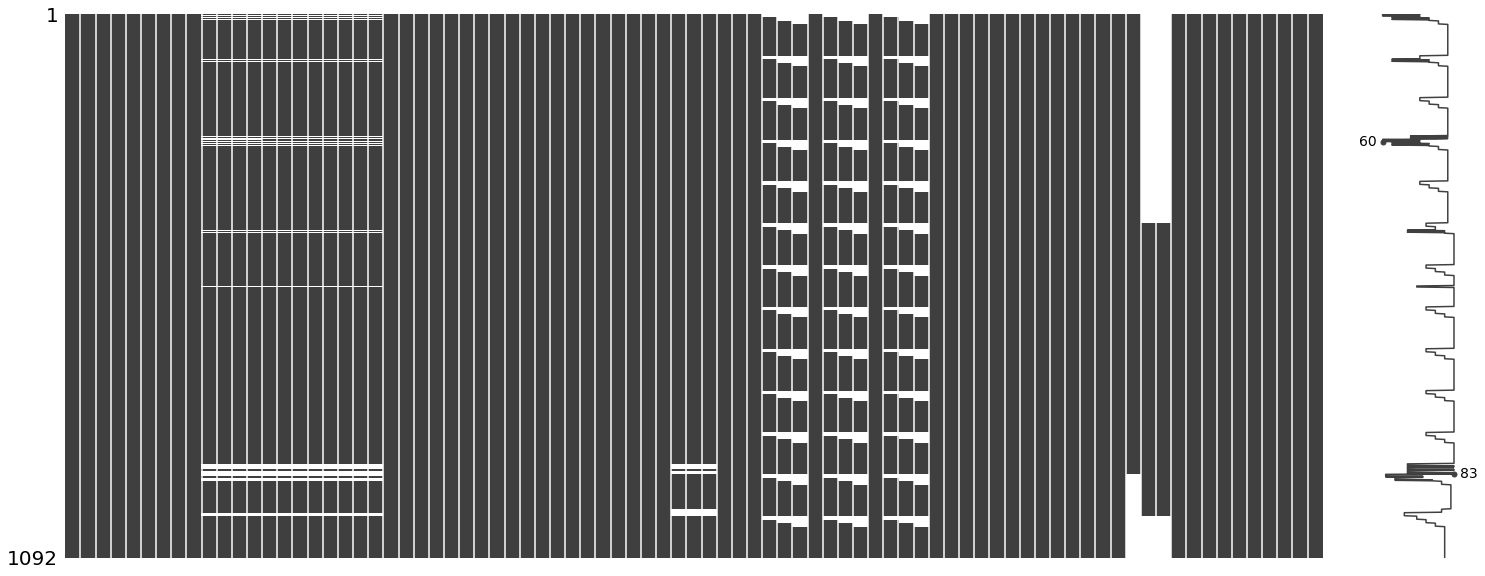

In [11]:
missingno.matrix(dataset)

In [12]:
cols = dataset.columns
cols

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [13]:
len(cols)

83

In [14]:
landcover = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [15]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [18]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [19]:
data_years = dataset['year'].unique().tolist()

In [20]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [21]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2011
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2012
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2013
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2014
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2015
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2016
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2017
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2018
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2019
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2020
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2021
Min distance: 3.5410560677416845
Max distance: 9.108256052446174
Year: 2022
Min distance: 3.5410560677416845
Max distance: 9.108256052446174


In [22]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

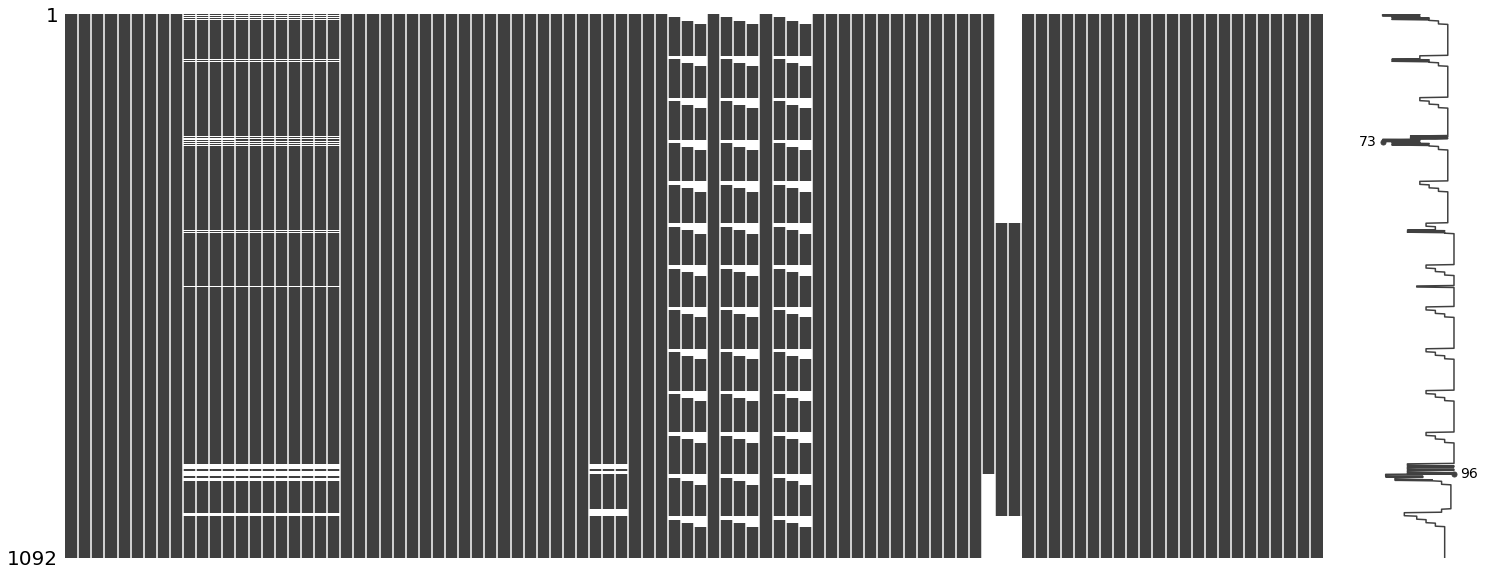

In [23]:
missingno.matrix(dataset_final)

In [24]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [25]:
len(cols)

96

In [26]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)